In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# Use moon dataset from sklean for real world usecase
X_np , Y_np = make_moons(n_samples=10000 , noise = 0.1 , random_state=42)

df = pd.DataFrame(X_np , columns=["x" , "y"])
df["label"] = Y_np

# saving the data to data.csv for gradio 
# app and visualizer to have the new points
df.to_csv("data.csv" , index = False) 

print(df.head())

          x         y  label
0  0.455493 -0.125503      1
1 -0.704217  0.041308      0
2  0.413799  0.791322      0
3 -0.864049  0.138754      0
4 -0.936268  0.359267      0


In [3]:
# Seperate X and Y

# X contains 2 points -> x , y
X = torch.tensor(
    df[["x" , "y"]].values,
    dtype=torch.float32 
)

# Y contains 0/1 label 
Y = torch.tensor(
    df["label"].values,
    dtype = torch.float32 
).reshape(-1, 1)

print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")

X shape : torch.Size([10000, 2])
Y shape : torch.Size([10000, 1])


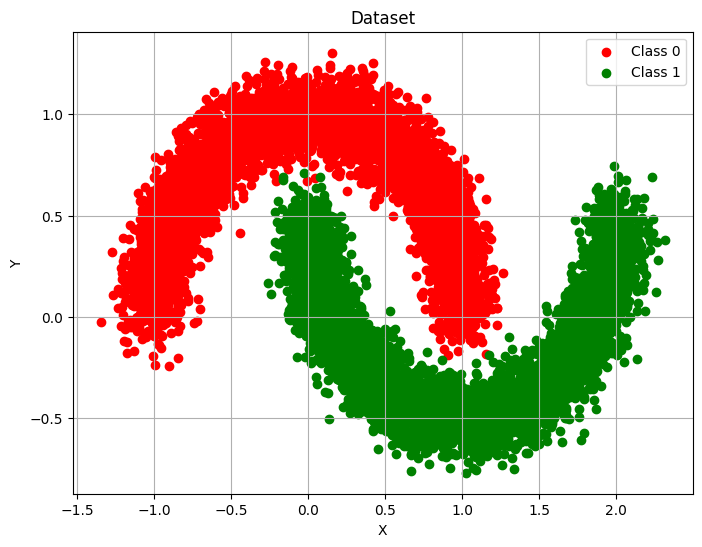

In [4]:
# Select class 0 points.
class_0 = X[Y[:, 0] == 0]

# Select class 1 points.
class_1 = X[Y[:, 0] == 1]


plt.figure(figsize=(8, 6))

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    color="red",
    label="Class 0"
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    color="green",
    label="Class 1"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Dataset")

plt.legend()
plt.grid(True)

plt.show()


In [5]:
# Shuffle the data
torch.manual_seed(42)
num_samples = X.shape[0]
indices = torch.randperm(num_samples)

# 80% training data
train_size = int(0.8 * num_samples)
training_indices = indices[:train_size]

# 20% testing data
testing_indices = indices[train_size:]

# create training and testing data 
x_train = X[training_indices]
y_train = Y[training_indices]

x_test = X[testing_indices]
y_test = Y[testing_indices]

print(f"X training shape : {x_train.shape} | Y training shape : {y_train.shape}")
print(f"X testing shape : {x_test.shape} | Y testing shape : {y_test.shape}")

X training shape : torch.Size([8000, 2]) | Y training shape : torch.Size([8000, 1])
X testing shape : torch.Size([2000, 2]) | Y testing shape : torch.Size([2000, 1])


In [6]:
# Normalize the data

# calculate mean & std deviation from training data 
mean = x_train.mean(dim=0)
std = x_train.std(dim=0)

# normalize training data
x_train = (x_train - mean) / std 

# normalize testing data
x_test = (x_test - mean) / std

print(f"Train samples: {x_train.shape[0]} | Test samples: {x_test.shape[0]}")
print(f"Mean: {mean} | Std: {std}")

Train samples: 8000 | Test samples: 2000
Mean: tensor([0.4970, 0.2493]) | Std: tensor([0.8775, 0.5034])


In [7]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2 , 16)
        self.layer2 = nn.Linear(16 , 16)
        self.output = nn.Linear(16 , 1)

    def forward(self , x):
        x = torch.tanh(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = self.output(x)

        return x 

model = Net()
print(model)

Net(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=1, bias=True)
)


In [310]:
# loss function
# BCEWithLogitsLoss() -> sigmoid + binary cross entropy
criterion = nn.BCEWithLogitsLoss()

# optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr = 0.01
)

In [311]:
from torch.utils.data import DataLoader , TensorDataset
# Train the network with full batch training
# epochs = 500
loss_history = []

# for epoch in range(epochs):
#     # 1. forward pass 
#     preds = model(x_train)

#     # 2. Compute loss 
#     loss = criterion(
#         preds,
#         y_train
#     )

#     # 3. clear gradients 
#     optimizer.zero_grad()

#     # 4. Back prop 
#     loss.backward()

#     # 5. Compute gradient descent 
#     optimizer.step()

# Mini-batch training 
epochs = 50
batch_size = 32
train_dataset = TensorDataset(x_train , y_train)
train_loader = DataLoader(train_dataset , batch_size)

for epoch in range(epochs):
    model.train()

    for xb , yb in train_loader:
        # 1. Forward pass 
        preds = model(xb)

        # 2. Compute loss 
        loss = criterion(preds , yb)

        # 3. Clear gradients 
        optimizer.zero_grad()

        # 4. Back prop 
        loss.backward()

        # 5. Gradient Descent / Optimization
        optimizer.step()

    loss_history.append(loss.item())

    # Print progress.
    if epoch % 5 == 0:

        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss.item():.4f}"
        )

Epoch: 0 | Loss: 0.2280
Epoch: 5 | Loss: 0.0109
Epoch: 10 | Loss: 0.0041
Epoch: 15 | Loss: 0.0015
Epoch: 20 | Loss: 0.0006
Epoch: 25 | Loss: 0.0003
Epoch: 30 | Loss: 0.0002
Epoch: 35 | Loss: 0.0001
Epoch: 40 | Loss: 0.0001
Epoch: 45 | Loss: 0.0001


In [312]:
# save the model
torch.save(model.state_dict(), "model.pth")

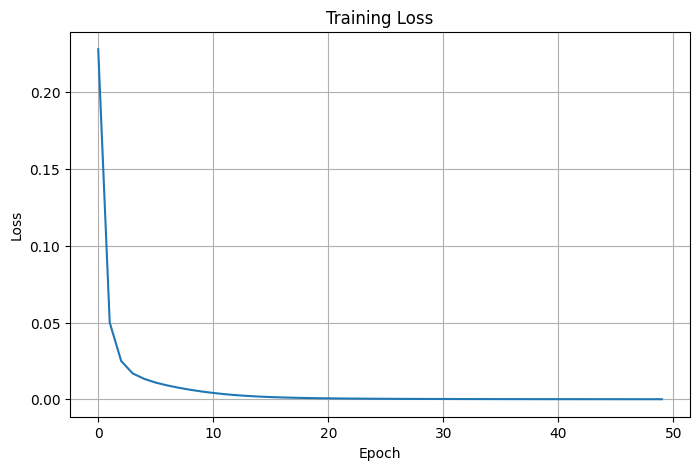

In [313]:
# Plot the training loss

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()


In [314]:
# Evaluate test data

model.eval()

# Disable gradient calculation because we aren't training.
with torch.no_grad():
    test_logits = model(x_test)

# Convert logits into probabilities.
#
# sigmoid converts:
#
#     -large number → close to 0
#     +large number → close to 1
#
test_probabilities = torch.sigmoid(test_logits)

# convert probs into classes
test_predictions = (
    test_probabilities >= 0.5
).float()

# Calculate accuracy.
accuracy = (
    test_predictions == y_test
).float().mean()

print(
    f"Test accuracy: {accuracy.item() * 100:.2f}%"
)

Test accuracy: 100.00%


In [315]:
# Find the range of the original data.
#
# We use X here before normalization because we want
# our final graph to use the original coordinate system.

x_min = X[:, 0].min() - 1
x_max = X[:, 0].max() + 1

y_min = X[:, 1].min() - 1
y_max = X[:, 1].max() + 1


# Number of points along each dimension.
grid_size = 300


# Create evenly spaced x and y coordinates.
grid_x = torch.linspace(
    x_min,
    x_max,
    grid_size
)

grid_y = torch.linspace(
    y_min,
    y_max,
    grid_size
)


# Create a 2D coordinate grid.
xx, yy = torch.meshgrid(
    grid_x,
    grid_y,
    indexing="xy"
)


In [316]:
# Flatten the coordinate grids.
#
# xx contains all x coordinates.
# yy contains all y coordinates.

grid_points = torch.stack(
    [
        xx.flatten(),
        yy.flatten()
    ],
    dim=1
)


print(grid_points.shape)


torch.Size([90000, 2])


In [317]:
# The neural network was trained on normalized inputs
# So our grid also needs to be normalized.
grid_points_normalized = (
    grid_points - mean
) / std

In [318]:
# Don't calculate gradients because we're only
# using the trained model for prediction.

with torch.no_grad():

    # Get raw network outputs.
    grid_logits = model(
        grid_points_normalized
    )

    # Convert logits into probabilities.
    grid_probabilities = torch.sigmoid(
        grid_logits
    )


# Convert the predictions back into the
# 300 × 300 grid shape.

Z = grid_probabilities.reshape(
    grid_size,
    grid_size
)


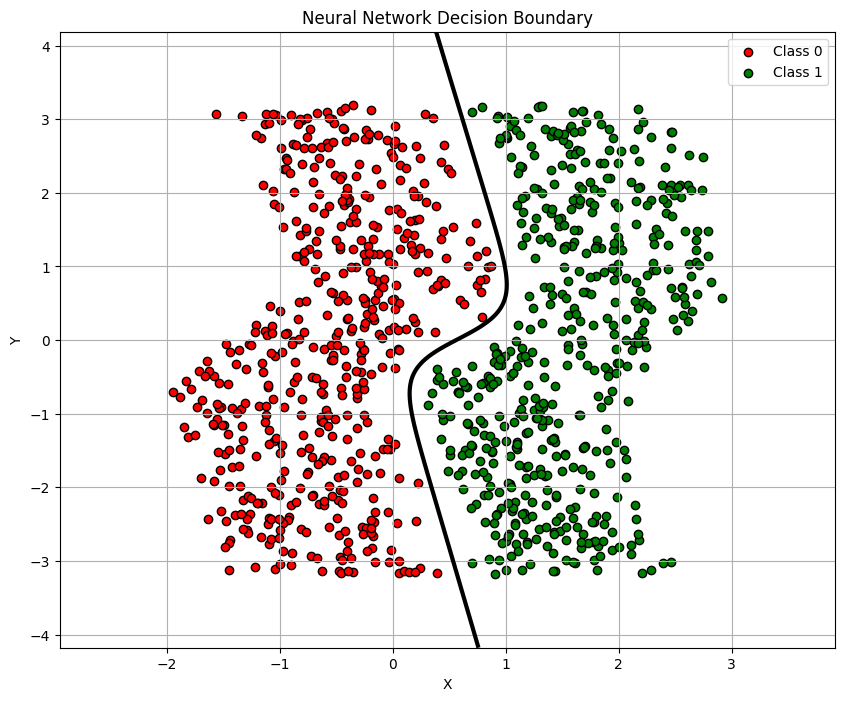

In [319]:
plt.figure(figsize=(10, 8))


# ----------------------------------------------------------
# Plot the original points.
# ----------------------------------------------------------

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    color="red",
    label="Class 0",
    edgecolors="black"
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    color="green",
    label="Class 1",
    edgecolors="black"
)


# ----------------------------------------------------------
# Draw the decision boundary.
#
# The boundary is where:
#
#     probability = 0.5
#
# ----------------------------------------------------------

plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    colors="black",
    linewidths=3
)


plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    "Neural Network Decision Boundary"
)

plt.legend()
plt.grid(True)

plt.show()


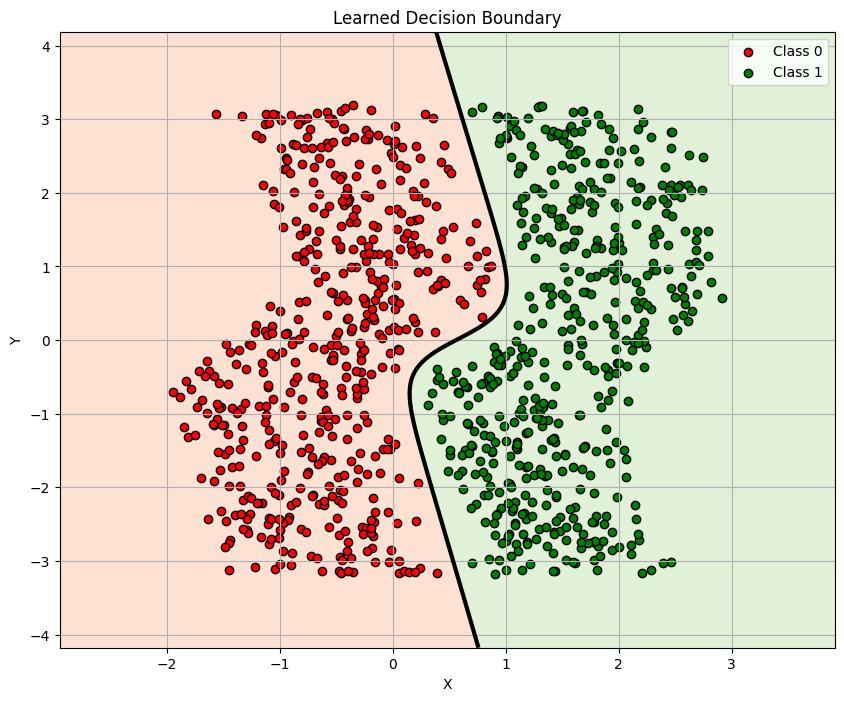

In [320]:
plt.figure(figsize=(10, 8))


# ----------------------------------------------------------
# Background color represents the network's prediction.
# ----------------------------------------------------------

plt.contourf(
    xx,
    yy,
    Z,
    levels=[0, 0.5, 1],
    cmap="RdYlGn",
    alpha=0.25
)


# ----------------------------------------------------------
# Original data points.
# ----------------------------------------------------------

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    color="red",
    label="Class 0",
    edgecolors="black"
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    color="green",
    label="Class 1",
    edgecolors="black"
)


# ----------------------------------------------------------
# Exact 0.5 boundary.
# ----------------------------------------------------------

plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    colors="black",
    linewidths=3
)


plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    "Learned Decision Boundary"
)

plt.legend()
plt.grid(True)

plt.show()
